# Array-Length Normalization: Train/Inference Mismatch Experiment

**Hypothesis.** When `model_array_lengths=True`, the continuous head is trained to
regress a *normalized* array length, `length / norm`, with bin width `1 / norm`
(`collator.py:_get_array_normalization`). The divisor `norm` is:

- the array path's inferred `maxItems` **iff** a schema PDA is present in the training
  collator — which only happens when `TrainingConfig.constrain_schema=True`
  (`trainer.py:260-270`);
- otherwise the hard-coded `DEFAULT_MAX_ARRAY = 20`.

At inference, the generator samples the length and **hard-enforces** it, normalizing by
the inferred `maxItems` whenever `InferenceConfig.constrain_schema=True`
(`generator.py:879-896`).

So if `train.constrain_schema=False` but `inference.constrain_schema=True`, the head
learns in `/20` units but is decoded in `/maxItems` units:

```
trained:   target      = true_len / 20
inference: sampled_len ~= head_output * maxItems
        => sampled_len ~= true_len * (maxItems / 20)
```

Two distortions follow: (1) a linear rescale by `maxItems/20`, and (2) **saturation** —
any `true_len > 20` clamps the training target to 1.0 (boundary absorption in the
discretized-logistic NLL, `heads.py:237-238`), so those lengths become unrecoverable.

**Design.** We make the bug maximally visible: array lengths are bimodal, one cluster
well below 20 and one cluster well above it, so `maxItems` is far from 20 *and* the long
cluster sits in the saturation zone. We then sweep training constraints while holding
inference constraints fixed (grammar+schema on, lengths enforced), exactly mirroring the
real-world observation.

| Run | `train.constrain_grammar` | `train.constrain_schema` | `model_array_lengths` | predicted |
|-----|:--:|:--:|:--:|---|
| 1. matched (good)        | ✓ | ✓ | ✓ | lengths match real |
| 2. schema-off (mismatch) | ✓ | ✗ | ✓ | **distorted** (rescale + saturation) |
| 3. grammar-off only      | ✗ | ✓ | ✓ | lengths match real (grammar irrelevant) |
| 4. both-off (user-worse) | ✗ | ✗ | ✓ | **distorted** (same as 2) |
| 5. no length head        | ✓ | ✓ | ✗ | discrete-head baseline |

Inference is identical for all runs: `constrain_grammar=True`, `constrain_schema=True`,
`enforce_array_lengths=True`.

If the theory holds: **1 ≈ 3 (good), 2 ≈ 4 (bad), 5 = baseline** — proving the schema flag
(via normalization), not the grammar flag, is the lever.


In [1]:
import random
from collections import Counter

import numpy as np

np.random.seed(16)
random.seed(16)

# --- knobs (reduce for a faster smoke run) ---
DEVICE = "mps"  # "mps", "cpu", or "auto"
N_SAMPLES = 6_000
EPOCHS = 30
N_GEN = 3_000


# --- toy data: bimodal array length straddling DEFAULT_MAX_ARRAY (=20) ---
# short cluster ~5 (below 20), long cluster ~35 (above 20 -> saturation zone).
# maxItems will be inferred as ~40, far from the hard-coded 20.
def sample_length():
    if random.random() < 0.5:
        return random.randint(2, 8)  # short cluster
    return random.randint(30, 40)  # long cluster


items_vocab = ["gold", "silver", "gem", "potion", "scroll", "ring", "amulet"]
regions = ["north", "south", "east", "west"]

data = []
for _ in range(N_SAMPLES):
    n = sample_length()
    data.append(
        {
            "region": random.choice(regions),
            # NOTE: no explicit "length" field -- the model must model length itself,
            # not copy it from a leaked field.
            "items": random.choices(items_vocab, k=n),
        }
    )

split = int(0.9 * N_SAMPLES)
train_data, eval_data = data[:split], data[split:]

real_lengths = [len(d["items"]) for d in data]
print(f"max array length (=> inferred maxItems): {max(real_lengths)}")
print(f"DEFAULT_MAX_ARRAY used when schema is absent at train time: 20")
print(f"mean length: {np.mean(real_lengths):.2f}")

counts = Counter(real_lengths)
print("\nlength distribution:")
for k in sorted(counts):
    pct = counts[k] / N_SAMPLES * 100
    print(f"  {k:2d}: {'#' * int(pct)} {pct:4.1f}%")

max array length (=> inferred maxItems): 40
DEFAULT_MAX_ARRAY used when schema is absent at train time: 20
mean length: 20.28

length distribution:
   2: #######  7.0%
   3: #######  7.1%
   4: #######  7.3%
   5: ######  6.8%
   6: #######  7.1%
   7: ######  6.8%
   8: ######  6.8%
  30: ####  4.5%
  31: ####  4.8%
  32: #####  5.0%
  33: ####  4.6%
  34: ####  4.7%
  35: #####  5.2%
  36: ####  4.5%
  37: ####  4.6%
  38: ####  4.1%
  39: ####  4.5%
  40: ####  4.6%


## Run the sweep

A single helper builds each config, trains, and generates. Only the **training**
constraint flags and `model_array_lengths` vary; inference is held fixed.

In [2]:
from origami import InferenceConfig, ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig
from origami.config import DataConfig
from origami.training import NotebookCallback

SHARED_MODEL = dict(
    backbone="transformer",
    kvpe_pooling="sum",
    d_model=64,
    n_heads=8,
    n_layers=6,
    d_ff=784,
    dropout=0.0,
    num_mixture_components=10,
)


def run_experiment(name, *, train_grammar, train_schema, model_array_lengths):
    config = OrigamiConfig(
        data=DataConfig(
            infer_schema=True,  # schema always inferred & stored for inference
            numeric_mode="disabled",
            model_array_lengths=model_array_lengths,
        ),
        model=ModelConfig(**SHARED_MODEL),
        training=TrainingConfig(
            shuffle_keys=False,
            batch_size=64,
            warmup_steps=500,
            learning_rate=5e-4,
            constrain_grammar=train_grammar,
            constrain_schema=train_schema,
        ),
        inference=InferenceConfig(
            constrain_grammar=True,
            constrain_schema=True,
            enforce_array_lengths=True,
        ),
        device=DEVICE,
    )
    print(f"\n=== {name} ===")
    pipe = OrigamiPipeline(config)
    pipe.fit(
        train_data,
        eval_data=eval_data,
        epochs=EPOCHS,
        verbose=False,
        callbacks=[NotebookCallback()],
    )
    gen = pipe.generate(num_samples=N_GEN, temperature=1.0)
    lengths = [len(d["items"]) for d in gen if isinstance(d.get("items"), list)]
    print(f"  valid generated: {len(lengths)}/{len(gen)}   mean length: {np.mean(lengths):.2f}")
    return {"pipeline": pipe, "lengths": lengths}


experiments = [
    dict(name="1. matched (good)", train_grammar=True, train_schema=True, model_array_lengths=True),
    dict(name="2. schema-off (mismatch)", train_grammar=True, train_schema=False, model_array_lengths=True),
    dict(name="3. grammar-off only", train_grammar=False, train_schema=True, model_array_lengths=True),
    dict(name="4. both-off (user-worse)", train_grammar=False, train_schema=False, model_array_lengths=True),
    dict(name="5. no length head", train_grammar=True, train_schema=True, model_array_lengths=False),
]

results = {}
for exp in experiments:
    results[exp["name"]] = run_experiment(**exp)


=== 1. matched (good) ===
Numba available: True


  valid generated: 3000/3000   mean length: 20.42

=== 2. schema-off (mismatch) ===


  valid generated: 3000/3000   mean length: 20.39

=== 3. grammar-off only ===


  valid generated: 3000/3000   mean length: 20.21

=== 4. both-off (user-worse) ===


  valid generated: 3000/3000   mean length: 20.29

=== 5. no length head ===


  valid generated: 3000/3000   mean length: 20.08


## Confirm the two divisors are actually different

The mechanism only bites if the inferred `maxItems` differs from `DEFAULT_MAX_ARRAY=20`.
Pull the inferred value out of the stored schema and contrast it.

In [3]:
def find_max_items(schema):
    """Walk an inferred schema and return the first array maxItems found."""
    if isinstance(schema, dict):
        if schema.get("type") == "array" and "maxItems" in schema:
            return schema["maxItems"]
        for v in schema.values():
            hit = find_max_items(v)
            if hit is not None:
                return hit
    return None


schema = results["1. matched (good)"]["pipeline"]._schema
inferred = find_max_items(schema)
print(f"inferred maxItems (used at inference, and at train iff constrain_schema=True): {inferred}")
print(f"lengths > 20 are saturated to target 1.0 during training in the schema-off runs.")

inferred maxItems (used at inference, and at train iff constrain_schema=True): 40
lengths > 20 are saturated to target 1.0 during training in the schema-off runs.


## Analyze: distributions + distinguishability

For each run we overlay the generated length distribution on the real one and report:

- **Wasserstein distance** between real and generated lengths (0 = identical).
- **Classifier AUC**: a logistic regression on `[length, length^2]` trying to separate
  real from synthetic. ~0.5 means indistinguishable; ~1.0 means trivially separable —
  the exact "a classifier can tell them apart" symptom that motivated this.

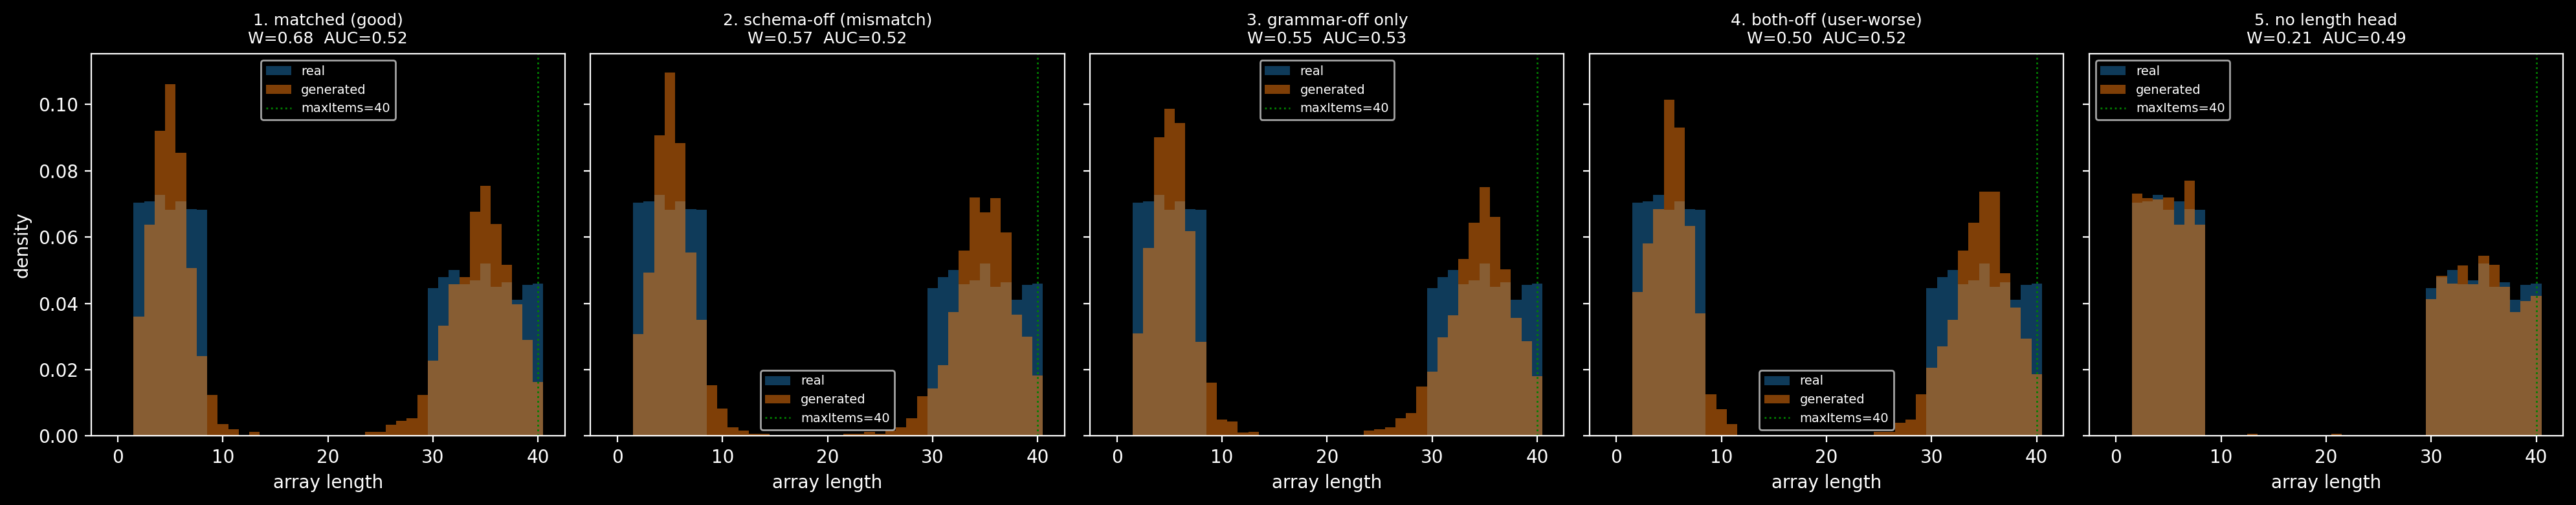

run                          Wasserstein  classifier AUC
--------------------------------------------------------
1. matched (good)                  0.677           0.520
2. schema-off (mismatch)           0.566           0.523
3. grammar-off only                0.555           0.530
4. both-off (user-worse)           0.496           0.525
5. no length head                  0.206           0.488


In [5]:
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def distinguishability_auc(real, fake):
    real, fake = list(real), list(fake)
    X = np.array([[v, v * v] for v in real + fake], dtype=float)
    y = np.array([0] * len(real) + [1] * len(fake))
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    return cross_val_score(clf, X, y, cv=3, scoring="roc_auc").mean()


names = [e["name"] for e in experiments]
bins = np.arange(0, max(real_lengths) + 2) - 0.5

fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4), sharey=True, dpi=200)
metrics = {}
for ax, name in zip(axes, names):
    gen_lengths = results[name]["lengths"]
    w = wasserstein_distance(real_lengths, gen_lengths)
    auc = distinguishability_auc(real_lengths, gen_lengths)
    metrics[name] = (w, auc)

    ax.hist(real_lengths, bins=bins, density=True, alpha=0.5, label="real", color="tab:blue")
    ax.hist(gen_lengths, bins=bins, density=True, alpha=0.5, label="generated", color="tab:orange")
    # ax.axvline(DEFAULT_MAX_ARRAY, color="red", ls="--", lw=1, label="DEFAULT=20")
    ax.axvline(inferred, color="green", ls=":", lw=1, label=f"maxItems={inferred}")
    ax.set_title(f"{name}\nW={w:.2f}  AUC={auc:.2f}", fontsize=9)
    ax.set_xlabel("array length")
    ax.legend(fontsize=7)
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

print(f"{'run':<28}{'Wasserstein':>12}{'classifier AUC':>16}")
print("-" * 56)
for name in names:
    w, auc = metrics[name]
    print(f"{name:<28}{w:>12.3f}{auc:>16.3f}")

## What to look for

Reading the table/plots against the prediction:

- **Run 1 (matched) and Run 3 (grammar-off)** should have low Wasserstein and AUC near 0.5
  — generated lengths track the real bimodal shape. Run 3 matching Run 1 shows the
  **grammar** flag is irrelevant to length quality.
- **Run 2 (schema-off) and Run 4 (both-off)** should show the distortion: the short
  cluster shifted up by ~`maxItems/20` and the long cluster collapsed onto `maxItems`
  (saturation), with high Wasserstein and AUC approaching 1.0. Run 4 = the user's
  "worse" setting; it matches Run 2, confirming **schema**, not grammar, is the cause.
- **Run 5 (no length head)** is the discrete-head baseline — no normalization involved,
  so it should not show the rescale/saturation signature (though it may model the long
  cluster less sharply for its own reasons).

If 2 ≈ 4 are distorted while 1 ≈ 3 ≈ 5 are not, the normalization-mismatch hypothesis is
confirmed and the fix is to decouple the length-normalization divisor from
`constrain_schema` (derive per-path `maxItems` whenever a schema is available and use it
in the collator regardless of whether schema *masking* is applied to the loss).